# PHSX 256 Topic 12: Numerical Differentiation and Integration

In [3]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

# Reproducible noise for synthetic data examples
rng = np.random.default_rng(0)


Matplotlib is building the font cache; this may take a moment.


## The core idea: finite differences from Taylor series

Numerical differentiation replaces the limit definition

$ f'(x) = \lim_{h\to 0} \frac{f(x+h)-f(x)}{h} $

with a small but finite step $h$.

### Forward difference

$ f'(x) \approx \frac{f(x+h)-f(x)}{h} $

Using a Taylor expansion,

$ f(x+h) = f(x) + h f'(x) + \frac{h^2}{2} f''(x) + \cdots $

Rearranging shows the leading error term is proportional to $h$:

$ \frac{f(x+h)-f(x)}{h} = f'(x) + \frac{h}{2} f''(x) + O(h^2) $

So the **forward difference** has **truncation error** $O(h)$.

### Backward difference

$ f'(x) \approx \frac{f(x)-f(x-h)}{h} $

It also has truncation error $O(h)$.

### Centered difference (better accuracy)

Combine forward and backward expansions to cancel the $O(h)$ term:

$ f'(x) \approx \frac{f(x+h)-f(x-h)}{2h} $

The leading error is now $O(h^2)$:

$ \frac{f(x+h)-f(x-h)}{2h} = f'(x) + \frac{h^2}{6} f^{(3)}(x) + O(h^4) $

That means for smooth functions, centered differences are usually much more accurate than one-sided differences for the same step size.

---

## Two competing errors: truncation vs round-off

If you take $h$ too large, truncation error dominates. If you take $h$ too small, floating-point round-off error dominates because you subtract nearly equal numbers.

A common rule-of-thumb for first derivatives in double precision is that a good scale is near:

$ h \sim \sqrt{\epsilon}\,L $

where $\epsilon \approx 2.2\times 10^{-16}$ is machine epsilon and $L$ is a characteristic scale of $x$.

In practice you often experiment with $h$ and check stability.


In [4]:
# Finite-difference derivative functions for analytic f(x)

def d1_forward(f, x, h):
    # First derivative: forward difference, O(h)
    return (f(x + h) - f(x)) / h


def d1_backward(f, x, h):
    # First derivative: backward difference, O(h)
    return (f(x) - f(x - h)) / h


def d1_centered(f, x, h):
    # First derivative: centered difference, O(h^2)
    return (f(x + h) - f(x - h)) / (2*h)


def d2_centered(f, x, h):
    # Second derivative: centered difference, O(h^2)
    return (f(x + h) - 2*f(x) + f(x - h)) / (h**2)


def d1_centered_5pt(f, x, h):
    # First derivative: 5-point centered stencil, O(h^4)
    return (-f(x+2*h) + 8*f(x+h) - 8*f(x-h) + f(x-2*h)) / (12*h)


def d2_centered_5pt(f, x, h):
    # Second derivative: 5-point centered stencil, O(h^4)
    return (-f(x+2*h) + 16*f(x+h) - 30*f(x) + 16*f(x-h) - f(x-2*h)) / (12*h**2)


## Example (math + physics): simple harmonic motion (function differentiation)

In simple harmonic motion (SHO), a displacement can be written as

$ x(t) = A\cos(\omega t) $

The velocity and acceleration are

$ v(t) = \frac{dx}{dt} = -A\omega\sin(\omega t) $

$ a(t) = \frac{d^2x}{dt^2} = -A\omega^2\cos(\omega t) = -\omega^2 x(t) $

We'll treat $x(t)$ as a known function and compute numerical derivatives using finite differences, then compare to the analytic expressions.


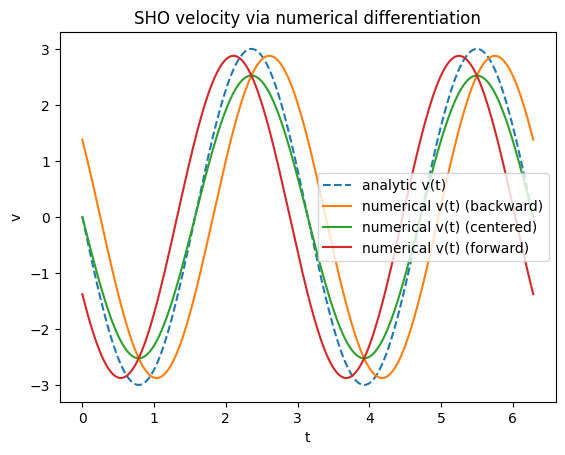

In [5]:
# SHO parameters
A = 1.5
omega = 2.0

# x(t) and analytic derivatives
x = lambda t: A*np.cos(omega*t)
v_true = lambda t: -A*omega*np.sin(omega*t)

# Evaluate on a grid
t = np.linspace(0, 2*np.pi, 400)

# Step size for differentiation
h = 5e-1

plt.figure()
plt.plot(t, v_true(t), "--", label="analytic v(t)")
plt.plot(t, d1_backward(x, t, h), label="numerical v(t) (backward)")
plt.plot(t, d1_centered(x, t, h), label="numerical v(t) (centered)")
plt.plot(t, d1_forward(x, t, h), label="numerical v(t) (forward)")
plt.xlabel("t")
plt.ylabel("v")
plt.legend()
plt.title("SHO velocity via numerical differentiation")
plt.show()


### Step size study (SHO): where is the sweet spot?

Because truncation error decreases as $h$ decreases, you might think smaller $h$ is always better. But round-off error grows when $h$ becomes extremely small.

A practical way to see this is to sweep $h$ values and plot the error.


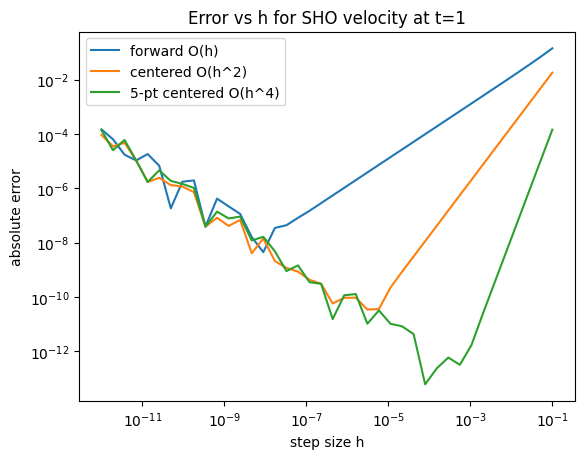

In [6]:
hs = np.logspace(-12, -1, 40)
errs_forward, errs_centered, errs_5pt = [], [], []

# Evaluate derivative at a single time where the derivative is not tiny
t0 = 1.0
v0_true = v_true(t0)

for h in hs:
    errs_forward.append(abs(d1_forward(x, t0, h) - v0_true))
    errs_centered.append(abs(d1_centered(x, t0, h) - v0_true))
    errs_5pt.append(abs(d1_centered_5pt(x, t0, h) - v0_true))

plt.figure()
plt.loglog(hs, errs_forward, label="forward O(h)")
plt.loglog(hs, errs_centered, label="centered O(h^2)")
plt.loglog(hs, errs_5pt, label="5-pt centered O(h^4)")
plt.xlabel("step size h")
plt.ylabel("absolute error")
plt.title("Error vs h for SHO velocity at t=1")
plt.legend()
plt.show()


## Example (physics): electric field from electric potential (function differentiation)

For a point charge $q$, the electric potential (in 1D radial form) is

$ V(r) = \frac{k q}{r} $

The electric field magnitude in the radial direction is related to the derivative:

$ E(r) = -\frac{dV}{dr} $

Analytically,

$ \frac{d}{dr}\left(\frac{1}{r}\right) = -\frac{1}{r^2} \Rightarrow E(r) = \frac{kq}{r^2} $

We'll compute $E(r)$ numerically from $V(r)$ and compare to the analytic $kq/r^2$.

Note: We avoid $r=0$ because the function diverges.


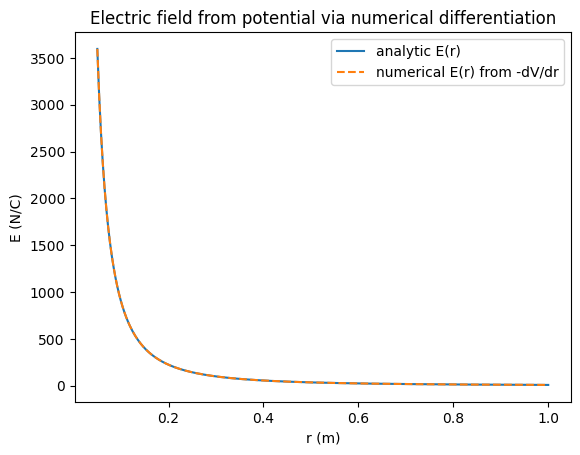

Max relative error (excluding endpoints): 3.7119590690044824e-06


In [7]:
k = 8.9875517923e9  # N·m^2/C^2
q = 1e-9            # C

V = lambda r: k*q/r
E_true = lambda r: k*q/r**2

r = np.linspace(0.05, 1.0, 500)
h = 1e-4

E_num = -d1_centered(V, r, h)

plt.figure()
plt.plot(r, E_true(r), label="analytic E(r)")
plt.plot(r, E_num, "--", label="numerical E(r) from -dV/dr")
plt.xlabel("r (m)")
plt.ylabel("E (N/C)")
plt.title("Electric field from potential via numerical differentiation")
plt.legend()
plt.show()

rel_err = np.max(np.abs(E_num[1:-1]-E_true(r)[1:-1]) / E_true(r)[1:-1])
print("Max relative error (excluding endpoints):", rel_err)


## Higher derivatives: curvature and second derivatives

Second derivatives appear all over physics:

- Acceleration is $a(t)=x''(t)$
- The 1D wave equation involves $\partial^2 y/\partial x^2$
- Potential energy curvature near equilibrium relates to oscillation frequency

### Centered second derivative

$ f''(x) \approx \frac{f(x+h) - 2f(x) + f(x-h)}{h^2} $

### 5-point second derivative

$ f''(x) \approx \frac{-f(x+2h)+16f(x+h)-30f(x)+16f(x-h)-f(x-2h)}{12h^2} $


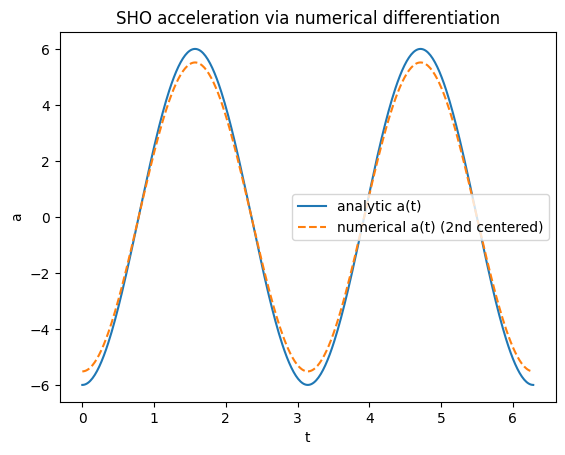

In [10]:
# SHO parameters
A = 1.5
omega = 2.0

# x(t) and analytic derivatives
x = lambda t: A*np.cos(omega*t)
a_true = lambda t: -A*omega**2*np.cos(omega*t)

# Evaluate on a grid
t = np.linspace(0, 2*np.pi, 400)

# Step size for differentiation
h = 5e-1

plt.figure()
plt.plot(t, a_true(t), label="analytic a(t)")
plt.plot(t, d2_centered(x, t, h), "--", label="numerical a(t) (2nd centered)")
plt.xlabel("t")
plt.ylabel("a")
plt.legend()
plt.title("SHO acceleration via numerical differentiation")
plt.show()


## Example (physics): small oscillations from potential curvature

Near a stable equilibrium point $x_0$,

$ k = \left.\frac{d^2U}{dx^2}\right|_{x_0} \quad \text{and} \quad \omega = \sqrt{\frac{k}{m}} $

Lennard-Jones potential:

$ U(r) = 4\varepsilon\left[\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6\right] $

We'll find the equilibrium point numerically and compute $k = U''(r_0)$.


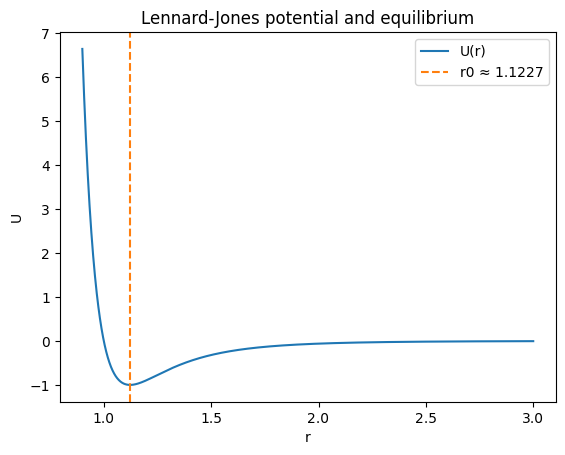

Equilibrium r0 ≈ 1.122711355677839
k = U''(r0) ≈ 56.88041431102982
omega = sqrt(k/m) ≈ 7.541910521282377


In [12]:
# Lennard-Jones parameters (choose convenient units)
epsilon = 1.0
sigma = 1.0
m = 1.0

U = lambda r: 4*epsilon*((sigma/r)**12 - (sigma/r)**6)

# Sample r values and locate the minimum approximately
r = np.linspace(0.9, 3.0, 2000)
U_vals = U(r)
idx0 = np.argmin(U_vals)
r0 = r[idx0]

h = 1e-4
k_num = d2_centered_5pt(U, r0, h)
omega_num = np.sqrt(k_num/m)

plt.figure()
plt.plot(r, U_vals, label="U(r)")
plt.axvline(r0, color="C1", linestyle="--", label=f"r0 ≈ {r0:.4f}")
plt.xlabel("r")
plt.ylabel("U")
plt.title("Lennard-Jones potential and equilibrium")
plt.legend()
plt.show()

print("Equilibrium r0 ≈", r0)
print("k = U''(r0) ≈", k_num)
print("omega = sqrt(k/m) ≈", omega_num)


## Differentiating numerical data (arrays)

For uniform spacing $\Delta x$:

$ f'(x_i) \approx \frac{f_{i+1} - f_{i-1}}{2\Delta x} $

At boundaries, use one-sided formulas (off-center). Second-order one-sided at left edge:

$ f'(x_0) \approx \frac{-3f_0 + 4f_1 - f_2}{2\Delta x} $

NumPy’s `np.gradient` uses centered differences inside and one-sided edges.


In [13]:
# Array-based finite differences for uniformly spaced data

def d1_data_centered(y, dx):
    # Interior centered, edges first-order one-sided
    dydx = np.empty_like(y, dtype=float)
    dydx[1:-1] = (y[2:] - y[:-2]) / (2*dx)
    dydx[0] = (y[1] - y[0]) / dx
    dydx[-1] = (y[-1] - y[-2]) / dx
    return dydx


def d1_data_edge2(y, dx):
    # Interior centered, edges second-order one-sided
    dydx = np.empty_like(y, dtype=float)
    dydx[1:-1] = (y[2:] - y[:-2]) / (2*dx)
    dydx[0] = (-3*y[0] + 4*y[1] - y[2]) / (2*dx)
    dydx[-1] = (3*y[-1] - 4*y[-2] + y[-3]) / (2*dx)
    return dydx


def d2_data_centered(y, dx):
    # Interior centered, edges second-order one-sided
    d2 = np.empty_like(y, dtype=float)
    d2[1:-1] = (y[2:] - 2*y[1:-1] + y[:-2]) / (dx**2)
    d2[0] = (2*y[0] - 5*y[1] + 4*y[2] - y[3]) / (dx**2)
    d2[-1] = (2*y[-1] - 5*y[-2] + 4*y[-3] - y[-4]) / (dx**2)
    return d2


## Example (physics, data): free-fall motion — velocity and acceleration from noisy position data

$ y(t) = y_0 + v_0 t - \frac{1}{2} g t^2 $

$ v(t) = v_0 - g t $

$ a(t) = -g $

We'll compare centered differences and `np.gradient` with different edge orders.


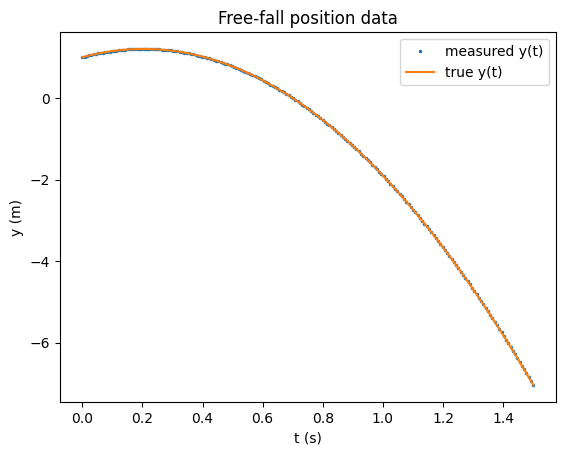

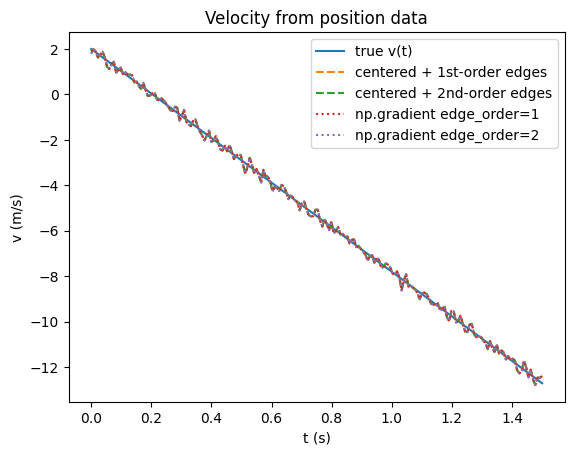

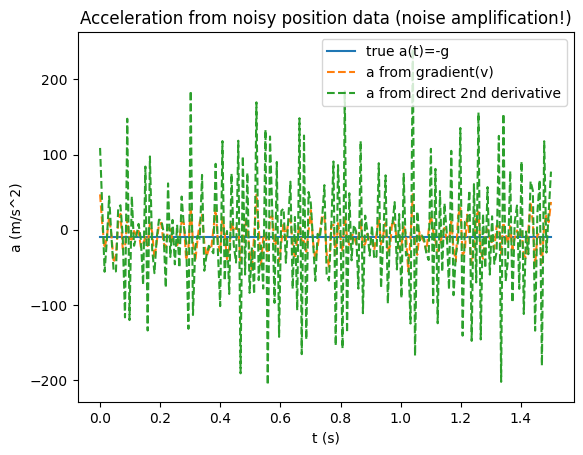

Estimated g from data (middle mean) ≈ 9.747093328769628


In [14]:
g = 9.81
v0 = 2.0
y0 = 1.0

N = 200
t = np.linspace(0, 1.5, N)
dt = t[1] - t[0]

y_true = y0 + v0*t - 0.5*g*t**2
noise = 0.002 * rng.standard_normal(size=N)
y_data = y_true + noise

v_c1 = d1_data_centered(y_data, dt)
v_c2 = d1_data_edge2(y_data, dt)

v_g1 = np.gradient(y_data, dt, edge_order=1)
v_g2 = np.gradient(y_data, dt, edge_order=2)

# acceleration

a_from_v = np.gradient(v_g2, dt, edge_order=2)
a_direct = d2_data_centered(y_data, dt)

a_true = -g*np.ones_like(t)

plt.figure()
plt.plot(t, y_data, '.', markersize=3, label='measured y(t)')
plt.plot(t, y_true, label='true y(t)')
plt.xlabel('t (s)')
plt.ylabel('y (m)')
plt.title('Free-fall position data')
plt.legend()
plt.show()

plt.figure()
plt.plot(t, v0 - g*t, label='true v(t)')
plt.plot(t, v_c1, '--', label='centered + 1st-order edges')
plt.plot(t, v_c2, '--', label='centered + 2nd-order edges')
plt.plot(t, v_g1, ':', label='np.gradient edge_order=1')
plt.plot(t, v_g2, ':', label='np.gradient edge_order=2')
plt.xlabel('t (s)')
plt.ylabel('v (m/s)')
plt.title('Velocity from position data')
plt.legend()
plt.show()

plt.figure()
plt.plot(t, a_true, label='true a(t)=-g')
plt.plot(t, a_from_v, '--', label='a from gradient(v)')
plt.plot(t, a_direct, '--', label='a from direct 2nd derivative')
plt.xlabel('t (s)')
plt.ylabel('a (m/s^2)')
plt.title('Acceleration from noisy position data (noise amplification!)')
plt.legend()
plt.show()

mid = slice(N//10, -N//10)
print('Estimated g from data (middle mean) ≈', -np.mean(a_from_v[mid]))


### A note on noise: smoothing before differentiating

Differentiation amplifies high-frequency noise. A simple moving average smoothing is

$ \tilde{y}_i = \frac{1}{M}\sum_{k=0}^{M-1} y_{i+k-M/2} $

We'll smooth and recompute acceleration.


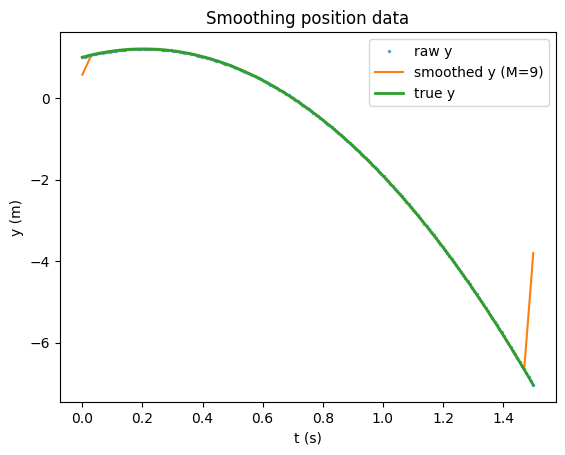

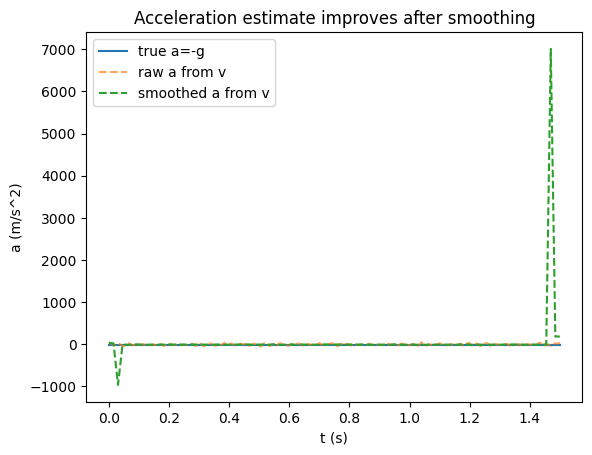

g estimate (raw): 9.747093328769628
g estimate (smoothed): 9.83992263296869


In [15]:
def moving_average(y, M):
    kernel = np.ones(M)/M
    return np.convolve(y, kernel, mode='same')

M = 9

y_smooth = moving_average(y_data, M)
v_smooth = np.gradient(y_smooth, dt, edge_order=2)
a_smooth = np.gradient(v_smooth, dt, edge_order=2)

plt.figure()
plt.plot(t, y_data, '.', markersize=3, alpha=0.6, label='raw y')
plt.plot(t, y_smooth, label=f'smoothed y (M={M})')
plt.plot(t, y_true, label='true y', linewidth=2)
plt.xlabel('t (s)')
plt.ylabel('y (m)')
plt.title('Smoothing position data')
plt.legend()
plt.show()

plt.figure()
plt.plot(t, -g*np.ones_like(t), label='true a=-g')
plt.plot(t, a_from_v, '--', alpha=0.7, label='raw a from v')
plt.plot(t, a_smooth, '--', label='smoothed a from v')
plt.xlabel('t (s)')
plt.ylabel('a (m/s^2)')
plt.title('Acceleration estimate improves after smoothing')
plt.legend()
plt.show()

mid = slice(N//10, -N//10)
print('g estimate (raw):', -np.mean(a_from_v[mid]))
print('g estimate (smoothed):', -np.mean(a_smooth[mid]))


## Centered vs off-center methods on data boundaries

For $y(x)=\sin(kx)$,

$ \frac{dy}{dx} = k\cos(kx) $

We compare boundary errors for first-order vs second-order one-sided edges.


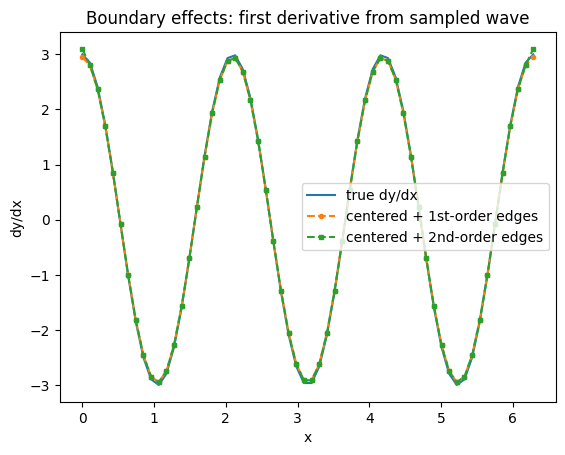

Left edge errors:
  1st-order edge: 0.050775187527771326
  2nd-order edge: 0.09846264114771319
Right edge errors:
  1st-order edge: 0.05077518752778021
  2nd-order edge: 0.09846264114770298


In [16]:
k = 3.0
x = np.linspace(0, 2*np.pi, 60)
dx = x[1] - x[0]

y = np.sin(k*x)
true_dydx = k*np.cos(k*x)

num1 = d1_data_centered(y, dx)
num2 = d1_data_edge2(y, dx)

plt.figure()
plt.plot(x, true_dydx, label='true dy/dx')
plt.plot(x, num1, 'o--', markersize=3, label='centered + 1st-order edges')
plt.plot(x, num2, 's--', markersize=3, label='centered + 2nd-order edges')
plt.xlabel('x')
plt.ylabel('dy/dx')
plt.title('Boundary effects: first derivative from sampled wave')
plt.legend()
plt.show()

print('Left edge errors:')
print('  1st-order edge:', abs(num1[0]-true_dydx[0]))
print('  2nd-order edge:', abs(num2[0]-true_dydx[0]))
print('Right edge errors:')
print('  1st-order edge:', abs(num1[-1]-true_dydx[-1]))
print('  2nd-order edge:', abs(num2[-1]-true_dydx[-1]))


## Example (physics, data): RC circuit discharge — estimating a time constant from $dV/dt$

$ V(t) = V_0 e^{-t/\tau} $

$ \frac{dV}{dt} = -\frac{1}{\tau}V(t) \Rightarrow \tau = -\frac{V}{dV/dt} $


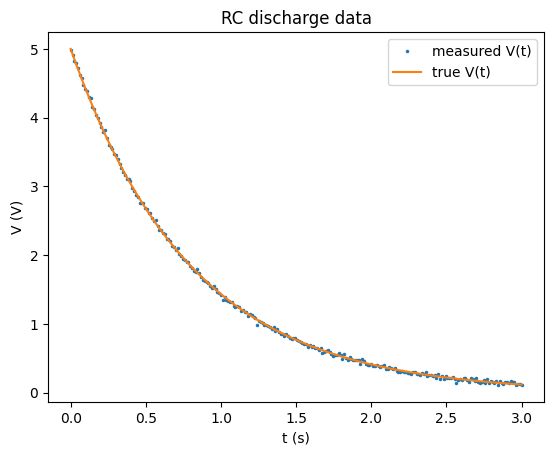

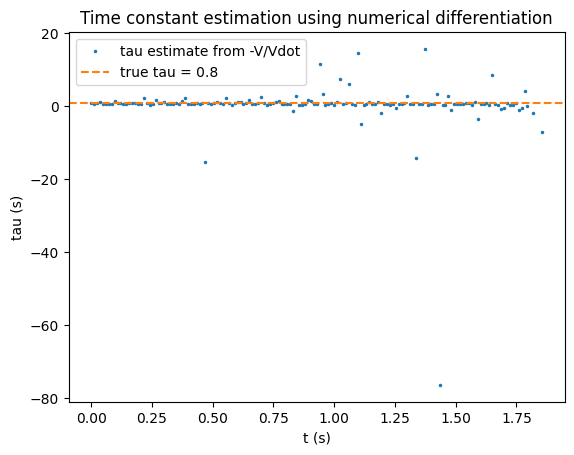

Estimated tau (median over mask) ≈ 0.7094375707213525


In [17]:
V0 = 5.0
true_tau = 0.8

t = np.linspace(0, 3.0, 250)
dt = t[1] - t[0]

V_true = V0*np.exp(-t/true_tau)
V_data = V_true + 0.02*rng.standard_normal(size=len(t))

Vdot = np.gradient(V_data, dt, edge_order=2)

mask = (V_data > 0.5)

tau_est = -V_data[mask] / Vdot[mask]

plt.figure()
plt.plot(t, V_data, '.', markersize=3, label='measured V(t)')
plt.plot(t, V_true, label='true V(t)')
plt.xlabel('t (s)')
plt.ylabel('V (V)')
plt.title('RC discharge data')
plt.legend()
plt.show()

plt.figure()
plt.plot(t[mask], tau_est, '.', markersize=3, label='tau estimate from -V/Vdot')
plt.axhline(true_tau, color='C1', linestyle='--', label=f'true tau = {true_tau}')
plt.xlabel('t (s)')
plt.ylabel('tau (s)')
plt.title('Time constant estimation using numerical differentiation')
plt.legend()
plt.show()

print('Estimated tau (median over mask) ≈', np.median(tau_est))


## Non-uniform spacing (physics, data): orbital motion sampled at irregular times

If samples are at irregular times $t_i$, use

$ v_i \approx \texttt{gradient}(x, t) $

We'll compare to the analytic derivative for $x(t)=A\cos(\omega t)$.


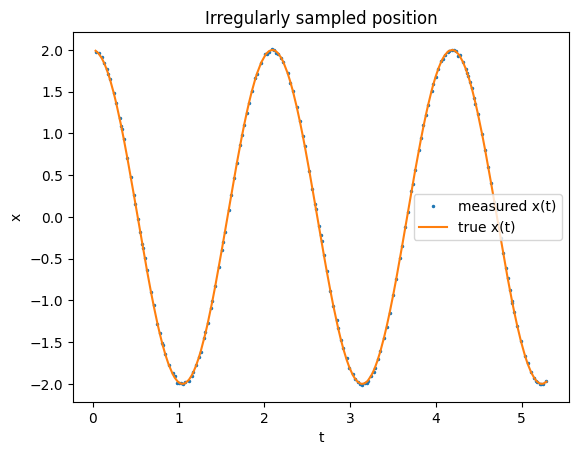

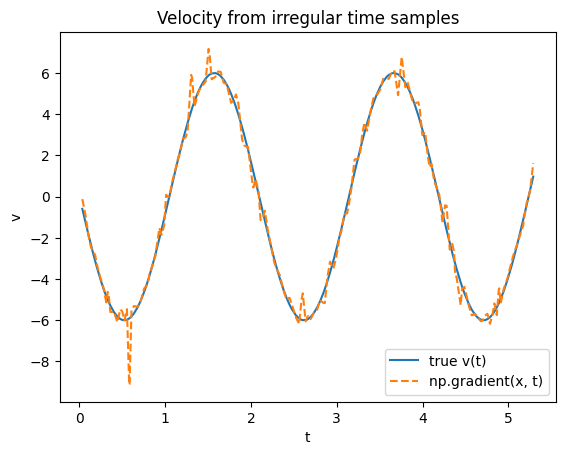

RMS velocity error: 0.541738358289855


In [18]:
A = 2.0
omega = 3.0

N = 180
steps = 0.03 + 0.01*rng.standard_normal(N)
steps = np.clip(steps, 0.005, None)
t = np.cumsum(steps)

x_true = A*np.cos(omega*t)
x_data = x_true + 0.01*rng.standard_normal(N)

v_true = -A*omega*np.sin(omega*t)
v_num = np.gradient(x_data, t, edge_order=2)

plt.figure()
plt.plot(t, x_data, '.', markersize=3, label='measured x(t)')
plt.plot(t, x_true, label='true x(t)')
plt.xlabel('t')
plt.ylabel('x')
plt.title('Irregularly sampled position')
plt.legend()
plt.show()

plt.figure()
plt.plot(t, v_true, label='true v(t)')
plt.plot(t, v_num, '--', label='np.gradient(x, t)')
plt.xlabel('t')
plt.ylabel('v')
plt.title('Velocity from irregular time samples')
plt.legend()
plt.show()

print('RMS velocity error:', np.sqrt(np.mean((v_num - v_true)**2)))


## Higher derivatives from data: second derivative and the wave equation idea

For $y(x)=\sin(kx)$,

$ \frac{d^2y}{dx^2} = -k^2\sin(kx) = -k^2 y(x) $

We'll compute $y''(x)$ from sampled data.


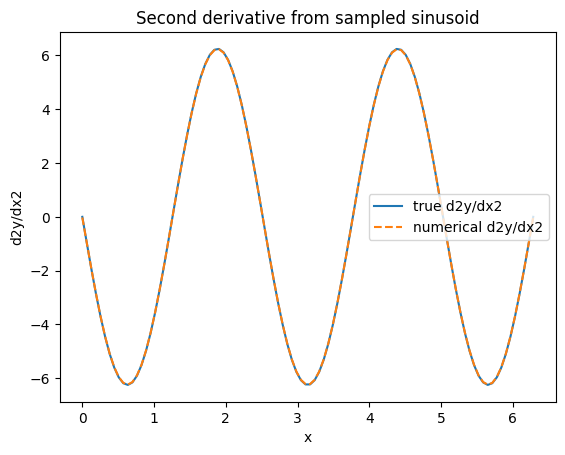

Max abs error: 0.024756411735369653


In [19]:
k = 2.5
x = np.linspace(0, 2*np.pi, 100)
dx = x[1] - x[0]

y = np.sin(k*x)
true_d2 = -(k**2)*np.sin(k*x)

num_d2 = d2_data_centered(y, dx)

plt.figure()
plt.plot(x, true_d2, label='true d2y/dx2')
plt.plot(x, num_d2, '--', label='numerical d2y/dx2')
plt.xlabel('x')
plt.ylabel('d2y/dx2')
plt.title('Second derivative from sampled sinusoid')
plt.legend()
plt.show()

print('Max abs error:', np.max(np.abs(num_d2 - true_d2)))


## Going beyond: estimating third derivatives (jerk) for motion

$ j(t) = \frac{d^3x}{dt^3} $

For SHO, if $x(t)=A\cos(\omega t)$ then

$ j(t) = A\omega^3\sin(\omega t) $

We'll compute jerk by applying `np.gradient` three times.


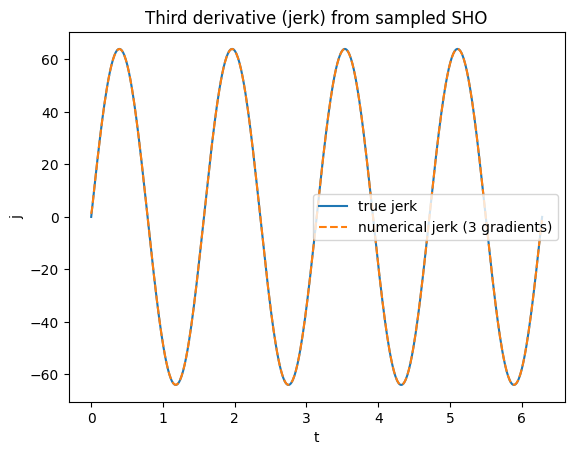

RMS jerk error: 0.07983237914471208


In [20]:
A = 1.0
omega = 4.0

t = np.linspace(0, 2*np.pi, 600)
dt = t[1] - t[0]

x = A*np.cos(omega*t)

v = np.gradient(x, dt, edge_order=2)
a = np.gradient(v, dt, edge_order=2)
j = np.gradient(a, dt, edge_order=2)

j_true = A*(omega**3)*np.sin(omega*t)

plt.figure()
plt.plot(t, j_true, label='true jerk')
plt.plot(t, j, '--', label='numerical jerk (3 gradients)')
plt.xlabel('t')
plt.ylabel('j')
plt.title('Third derivative (jerk) from sampled SHO')
plt.legend()
plt.show()

print('RMS jerk error:', np.sqrt(np.mean((j - j_true)**2)))


## Summary and practical advice

- For analytic functions, centered differences and higher-order stencils can be very accurate.
- For data, interior centered differences are standard; edges require one-sided (off-center) formulas.
- Differentiation amplifies noise; smoothing or fitting can help.


# Numerical Integration in Python

Integration is a core tool in physics:

- Work from force: $W = \int \vec{F}\cdot d\vec{r}$
- Impulse from force: $\vec{J} = \int \vec{F}\,dt = \Delta \vec{p}$
- Charge from current: $Q = \int I(t)\,dt$
- Energy from power: $E = \int P(t)\,dt$
- Potential difference from field: $\Delta V = -\int \vec{E}\cdot d\vec{\ell}$

We cover:

- Integrating known functions $f(x)$ on $[a,b]$
- Integrating numerical data $(x_i, y_i)$


## The core idea: area under a curve

$ \int_a^b f(x)\,dx = \lim_{N\to\infty} \sum_{i=0}^{N-1} f(x_i^*)\,\Delta x $

with $\Delta x = h = (b-a)/N$.


In [24]:
# Numerical integration helpers (NumPy only)

try:
    trapezoid_np = np.trapezoid
except AttributeError:
    trapezoid_np = np.trapz

# Function-based rules

def riemann_left(f, a, b, N):
    x = np.linspace(a, b, N+1)
    h = (b-a)/N
    return np.sum(f(x[:-1]))*h


def riemann_right(f, a, b, N):
    x = np.linspace(a, b, N+1)
    h = (b-a)/N
    return np.sum(f(x[1:]))*h


def riemann_midpoint(f, a, b, N):
    x = np.linspace(a, b, N+1)
    h = (b-a)/N
    xm = 0.5*(x[:-1] + x[1:])
    return np.sum(f(xm))*h


def trapz_function(f, a, b, N):
    x = np.linspace(a, b, N+1)
    return trapezoid_np(f(x), x)


def simpson_function(f, a, b, N):
    if N % 2 != 0:
        raise ValueError('Simpson requires even N (panels).')
    x = np.linspace(a, b, N+1)
    y = f(x)
    h = (b-a)/N
    return (h/3)*(y[0] + y[-1] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-1:2]))


def romberg_function(f, a, b, max_level=6):
    R = np.zeros((max_level, max_level), dtype=float)
    for k in range(max_level):
        N = 2**k
        R[k, 0] = trapz_function(f, a, b, N)
        for j in range(1, k+1):
            R[k, j] = R[k, j-1] + (R[k, j-1] - R[k-1, j-1])/(4**j - 1)
    return R

# Data-based

def trapz_data(x, y):
    return trapezoid_np(y, x)


def simpson_data_uniform(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    if (len(x)-1) % 2 != 0:
        raise ValueError('Simpson needs an even number of panels (odd number of points).')
    dxs = np.diff(x)
    if not np.allclose(dxs, dxs[0]):
        raise ValueError('x must be uniformly spaced for this Simpson implementation.')
    h = dxs[0]
    return (h/3)*(y[0] + y[-1] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-1:2]))


def cumulative_trapz(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    I = np.zeros_like(y, dtype=float)
    dx = np.diff(x)
    I[1:] = np.cumsum(0.5*(y[1:] + y[:-1]) * dx)
    return I


## Low-order methods and trapezoids

Left sum:

$ \int_a^b f(x)\,dx \approx \sum_{i=0}^{N-1} f(x_i)\,h $

Midpoint:

$ \int_a^b f(x)\,dx \approx \sum_{i=0}^{N-1} f\left(\frac{x_i+x_{i+1}}{2}\right)h $

Trapezoid:

$ \int_a^b f(x)\,dx \approx \sum_{i=0}^{N-1} \frac{f(x_i)+f(x_{i+1})}{2}h $


## Higher-order method: Simpson's rule

$ \int_a^b f(x)\,dx \approx \frac{h}{3}\left[f(x_0)+f(x_N)+4\sum_{\text{odd}} f(x_i)+2\sum_{\text{even}} f(x_i)\right] $

Typically $O(h^4)$ for smooth functions.


# Visualizing the shapes used by numerical integration rules

It helps to literally **see** the geometric pieces each rule adds up.

Let $h = (b-a)/N$.

- Left/right/midpoint rules use **rectangles**
- Trapezoidal rule uses **trapezoids**
- Simpson's rule uses **parabolic pieces** (quadratics) over pairs of panels

Below we draw these shapes directly under a curve.


In [25]:
from matplotlib.patches import Rectangle, Polygon

# Draw rectangles for left/right/midpoint

def draw_rectangles(ax, f, a, b, N, mode='left', color='C1'):
    x_edges = np.linspace(a, b, N+1)
    h = (b-a)/N

    if mode == 'left':
        x_s = x_edges[:-1]
    elif mode == 'right':
        x_s = x_edges[1:]
    elif mode == 'midpoint':
        x_s = 0.5*(x_edges[:-1] + x_edges[1:])
    else:
        raise ValueError('mode must be left/right/midpoint')

    y_s = f(x_s)

    for i in range(N):
        ax.add_patch(Rectangle((x_edges[i], 0), h, y_s[i], facecolor=color, edgecolor=color, alpha=0.25))


# Draw trapezoids

def draw_trapezoids(ax, f, a, b, N, color='C2'):
    x = np.linspace(a, b, N+1)
    y = f(x)

    for i in range(N):
        verts = [(x[i], 0), (x[i], y[i]), (x[i+1], y[i+1]), (x[i+1], 0)]
        ax.add_patch(Polygon(verts, closed=True, facecolor=color, edgecolor=color, alpha=0.25))

    ax.plot(x, y, 'o', color=color, ms=4)


# Draw Simpson parabolic pieces (quadratic through 3 points)

def draw_simpson_parabolas(ax, f, a, b, N, color='C3'):
    if N % 2 != 0:
        raise ValueError('Simpson drawing requires even N')

    x = np.linspace(a, b, N+1)
    y = f(x)

    for i in range(0, N, 2):
        x0, x1, x2 = x[i], x[i+1], x[i+2]
        y0, y1, y2 = y[i], y[i+1], y[i+2]

        coeff = np.polyfit([x0, x1, x2], [y0, y1, y2], 2)
        xs = np.linspace(x0, x2, 200)
        ys = np.polyval(coeff, xs)

        ax.plot(xs, ys, color=color, lw=2)
        ax.fill_between(xs, 0, ys, color=color, alpha=0.18)

    ax.plot(x, y, 'o', color=color, ms=4)


def plot_shapes_demo(f, a, b, N):
    x_fine = np.linspace(a, b, 1000)
    y_fine = f(x_fine)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # left rectangles
    ax = axes[0, 0]
    ax.plot(x_fine, y_fine, color='C0', lw=2)
    ax.axhline(0, color='k', lw=1)
    draw_rectangles(ax, f, a, b, N, mode='left')
    ax.set_title(f'Left rectangles, N={N}, h={(b-a)/N:.3g}')

    # midpoint rectangles
    ax = axes[0, 1]
    ax.plot(x_fine, y_fine, color='C0', lw=2)
    ax.axhline(0, color='k', lw=1)
    draw_rectangles(ax, f, a, b, N, mode='midpoint')
    ax.set_title(f'Midpoint rectangles, N={N}, h={(b-a)/N:.3g}')

    # trapezoids
    ax = axes[1, 0]
    ax.plot(x_fine, y_fine, color='C0', lw=2)
    ax.axhline(0, color='k', lw=1)
    draw_trapezoids(ax, f, a, b, N)
    ax.set_title(f'Trapezoids, N={N}, h={(b-a)/N:.3g}')

    # Simpson
    ax = axes[1, 1]
    ax.plot(x_fine, y_fine, color='C0', lw=2)
    ax.axhline(0, color='k', lw=1)
    draw_simpson_parabolas(ax, f, a, b, N)
    ax.set_title(f'Simpson parabolas, N={N}, h={(b-a)/N:.3g}')

    # consistent axes
    y_min = min(0.0, np.min(y_fine))*1.15
    y_max = max(0.0, np.max(y_fine))*1.15
    for ax in axes.ravel():
        ax.set_xlim(a, b)
        ax.set_ylim(y_min, y_max)
        ax.set_xlabel('x')
        ax.set_ylabel('y')

    plt.tight_layout()
    plt.show()


## Shape plots for $f(x)=\sin(x)$ on $[0,\pi]$

$ \int_0^{\pi} \sin(x)\,dx = 2 $

The shaded shapes are the actual geometric pieces each method sums.


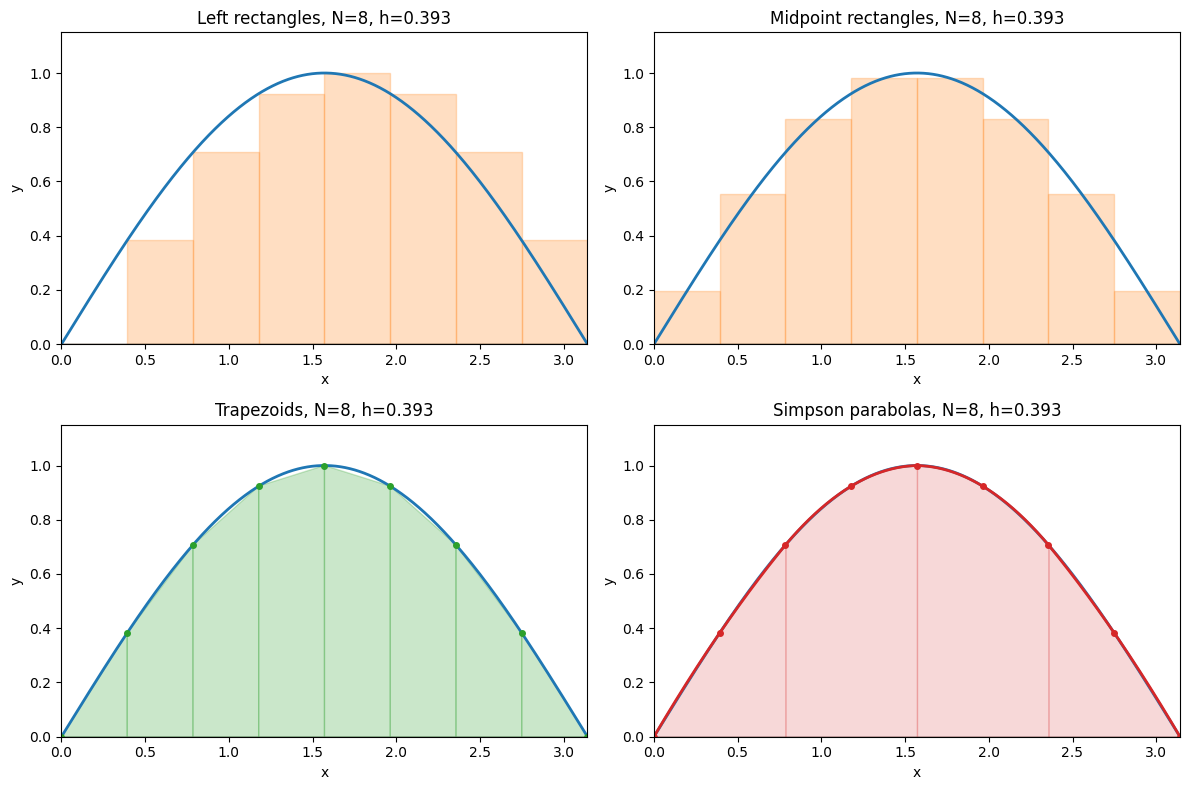

left     : 1.974231601945551
midpoint : 2.012909085599128
trapezoid: 1.9742316019455508
Simpson  : 2.0002691699483877
true     : 2.0


In [26]:
f = np.sin
a, b = 0.0, np.pi
N = 8

plot_shapes_demo(f, a, b, N)

print('left     :', riemann_left(f, a, b, N))
print('midpoint :', riemann_midpoint(f, a, b, N))
print('trapezoid:', trapz_function(f, a, b, N))
print('Simpson  :', simpson_function(f, a, b, N))
print('true     :', 2.0)


## Shape plots for a physics integrand: spring force $F(x)=-kx$

Because $F(x)<0$ for $x>0$, the trapezoids go below the axis. The signed area is negative work.


In [ ]:
k = 12.0
A = 0.8
F = lambda x: -k*x

x_fine = np.linspace(0, A, 1000)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_fine, F(x_fine), color='C0', lw=2)
ax.axhline(0, color='k', lw=1)

draw_trapezoids(ax, F, 0, A, N=6)
ax.set_title('Trapezoids under spring force F(x)=-kx')
ax.set_xlabel('x')
ax.set_ylabel('F')
plt.show()

print('True work:', -0.5*k*A**2)
print('Trapezoid estimate (N=6):', trapz_function(F, 0, A, 6))


## Example (physics, function integration): work done by a spring

$ F(x)=-kx $

$ W = \int_0^A F(x)\,dx = -\frac{1}{2}kA^2 $


In [ ]:
k = 12.0
A = 0.8
F = lambda x: -k*x

W_true = -0.5*k*A**2

Ns = [4, 8, 16, 32, 64, 128]
W_left, W_mid, W_trap, W_simp = [], [], [], []

for N in Ns:
    W_left.append(riemann_left(F, 0, A, N))
    W_mid.append(riemann_midpoint(F, 0, A, N))
    W_trap.append(trapz_function(F, 0, A, N))
    W_simp.append(simpson_function(F, 0, A, N))

# Integrand plot
x = np.linspace(0, A, 400)
plt.figure()
plt.plot(x, F(x), label='F(x)=-kx')
plt.fill_between(x, 0, F(x), alpha=0.2, label='area = work')
plt.xlabel('x (m)')
plt.ylabel('F (N)')
plt.title('Spring work as area under F(x)')
plt.legend()
plt.show()

# Convergence
err_left = np.abs(np.array(W_left) - W_true)
err_mid = np.abs(np.array(W_mid) - W_true)
err_trap = np.abs(np.array(W_trap) - W_true)
err_simp = np.abs(np.array(W_simp) - W_true)

plt.figure()
plt.loglog(Ns, err_left, 'o-', label='left sum')
plt.loglog(Ns, err_mid, 'o-', label='midpoint')
plt.loglog(Ns, err_trap, 'o-', label='trapezoid')
plt.loglog(Ns, err_simp, 'o-', label='Simpson')
plt.xlabel('N panels')
plt.ylabel('absolute error')
plt.title('Convergence for spring work')
plt.legend()
plt.show()

print('True work:', W_true)


## Example (physics, function integration): potential difference from electric field

$ E(r) = \frac{kq}{r^2} $

$ \Delta V = -\int_{r_0}^{r_1} E(r)\,dr = kq\left(\frac{1}{r_1}-\frac{1}{r_0}\right) $


In [ ]:
k = 8.9875517923e9
q = 1e-9
E = lambda r: k*q/(r**2)

r0 = 0.2
r1 = 1.0

dV_true = k*q*(1/r1 - 1/r0)

Ns = [10, 20, 40, 80, 160, 320]
vals_trap, vals_simp = [], []

for N in Ns:
    vals_trap.append(-trapz_function(E, r0, r1, N))
    vals_simp.append(-simpson_function(E, r0, r1, N))

R = romberg_function(lambda r: -E(r), r0, r1, max_level=6)
romberg_est = R[-1, -1]

r = np.linspace(r0, r1, 400)
plt.figure()
plt.plot(r, E(r))
plt.xlabel('r (m)')
plt.ylabel('E (N/C)')
plt.title('Electric field magnitude E(r)')
plt.show()

err_trap = np.abs(np.array(vals_trap) - dV_true)
err_simp = np.abs(np.array(vals_simp) - dV_true)

plt.figure()
plt.loglog(Ns, err_trap, 'o-', label='trapezoid')
plt.loglog(Ns, err_simp, 'o-', label='Simpson')
plt.axhline(abs(romberg_est - dV_true), color='C3', linestyle='--', label='Romberg')
plt.xlabel('N panels')
plt.ylabel('absolute error')
plt.title('Potential difference error vs N')
plt.legend()
plt.show()

print('True ΔV:', dV_true)
print('Romberg estimate:', romberg_est)


## Example (physics, data integration): impulse from force–time data

$ J = \int_{t_0}^{t_1} F(t)\,dt = \Delta p $


In [ ]:
# Synthetic force pulse data
N = 401
t = np.linspace(0, 0.20, N)

F0 = 50.0
mu = 0.10
sigma = 0.015
F_true = F0*np.exp(-0.5*((t-mu)/sigma)**2)

F_data = F_true + 1.5*rng.standard_normal(N)

J_true = F0 * sigma * np.sqrt(2*np.pi)

J_trap = trapz_data(t, F_data)
J_simp = simpson_data_uniform(t, F_data)
J_cum = cumulative_trapz(t, F_data)

plt.figure()
plt.plot(t, F_data, '.', markersize=2, alpha=0.6, label='measured F(t)')
plt.plot(t, F_true, label='true F(t)')
plt.xlabel('t (s)')
plt.ylabel('F (N)')
plt.title('Force pulse data')
plt.legend()
plt.show()

plt.figure()
plt.plot(t, J_cum, label='cumulative impulse J(t)')
plt.axhline(J_true, color='C1', linestyle='--', label=f'true J ≈ {J_true:.2f} N·s')
plt.xlabel('t (s)')
plt.ylabel('J (N·s)')
plt.title('Impulse as cumulative integral of force')
plt.legend()
plt.show()

print('True impulse:', J_true)
print('Trapezoid estimate:', J_trap)
print('Simpson estimate:', J_simp)


## Example (physics, data integration): displacement from velocity data

$ x(t) = x(t_0) + \int_{t_0}^{t} v(t')\,dt' $

For SHO, if $v(t)=-A\omega\sin(\omega t)$ then $x(t)=A\cos(\omega t)$.


In [ ]:
A = 1.2
omega = 5.0

N = 600
t = np.linspace(0, 2*np.pi/omega, N)

v_true = -A*omega*np.sin(omega*t)
v_data = v_true + 0.05*rng.standard_normal(N)

x0 = A
x_recon = x0 + cumulative_trapz(t, v_data)
x_true = A*np.cos(omega*t)

plt.figure()
plt.plot(t, v_data, '.', markersize=2, alpha=0.6, label='measured v(t)')
plt.plot(t, v_true, label='true v(t)')
plt.xlabel('t (s)')
plt.ylabel('v (m/s)')
plt.title('Velocity data for SHO')
plt.legend()
plt.show()

plt.figure()
plt.plot(t, x_true, label='true x(t)')
plt.plot(t, x_recon, '--', label='reconstructed x(t) from ∫v dt')
plt.xlabel('t (s)')
plt.ylabel('x (m)')
plt.title('Reconstructing position by numerical integration')
plt.legend()
plt.show()

print('RMS position error:', np.sqrt(np.mean((x_recon - x_true)**2)))


## Convergence on a smooth integral

$ \int_0^{\pi} \sin(x)\,dx = 2 $

We compare trapezoid vs Simpson.


In [ ]:
f = np.sin
I_true = 2.0

a, b = 0.0, np.pi
Ns = 2**np.arange(2, 10)

err_trap, err_simp = [], []
for N in Ns:
    err_trap.append(abs(trapz_function(f, a, b, int(N)) - I_true))
    err_simp.append(abs(simpson_function(f, a, b, int(N)) - I_true))

plt.figure()
plt.loglog(Ns, err_trap, 'o-', label='trapezoid')
plt.loglog(Ns, err_simp, 'o-', label='Simpson')
plt.xlabel('N panels')
plt.ylabel('absolute error')
plt.title('Convergence on ∫ sin(x) dx from 0 to π')
plt.legend()
plt.show()


## Practical advice for numerical integration

- Smooth functions: Simpson can converge quickly.
- Noisy data: higher-order rules may not help much; trapezoids are often robust.
- Non-uniform spacing: trapezoids work naturally; Simpson requires extra care.
